**Question 19**

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv


Most Recent Available Month: 2026-03


/tmp/ipykernel_57/2540816179.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift_df["data_month"] = pd.to_datetime(swift_df["data_month"], errors="coerce")


,Month,Currency,Global_Payment_Share,Unit
0,2026-03-01,USD,58.50,%
1,2026-03-01,USD,51.14,%
2,2026-03-01,EUR,21.30,%
3,2026-03-01,EUR,13.49,%
4,2026-03-01,GBP,6.54,%
5,2026-03-01,JPY,5.32,%
6,2026-03-01,GBP,5.00,%
7,2026-03-01,JPY,3.53,%
8,2026-03-01,CNY,3.10,%
9,2026-03-01,CAD,3.03,%


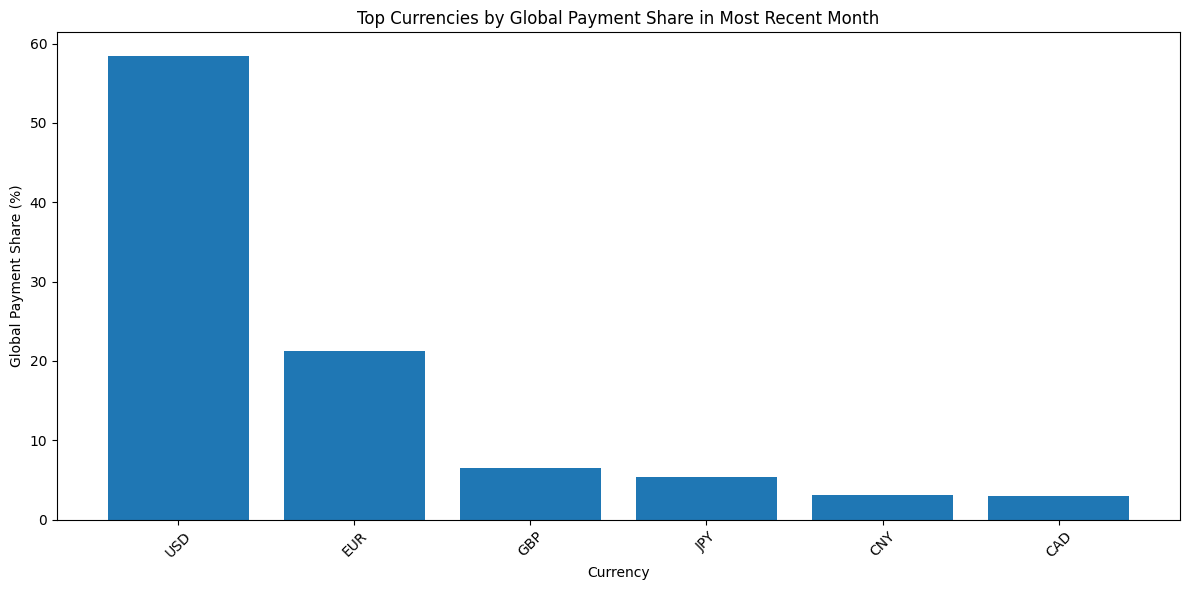

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

swift_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv")

swift_df["data_month"] = pd.to_datetime(swift_df["data_month"], errors="coerce")
swift_df["value"] = pd.to_numeric(swift_df["value"], errors="coerce")

payment_df = swift_df[swift_df["metric"].str.contains("payment", case=False, na=False)].copy()

latest_month = payment_df["data_month"].max()

latest_data = payment_df[payment_df["data_month"] == latest_month].copy()

top_table = latest_data.sort_values(by="value", ascending=False).head(10)[
    ["data_month", "currency_or_economy", "value", "unit"]
].reset_index(drop=True)

top_table.columns = ["Month", "Currency", "Global_Payment_Share", "Unit"]

print("Most Recent Available Month:", latest_month.strftime("%Y-%m"))
display(top_table)

top_table.to_csv("q19_top_currencies_global_payment_share.csv", index=False)

plt.figure(figsize=(12,6))
plt.bar(top_table["Currency"], top_table["Global_Payment_Share"])
plt.title("Top Currencies by Global Payment Share in Most Recent Month")
plt.xlabel("Currency")
plt.ylabel("Global Payment Share (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("q19_top_currencies_global_payment_share.pdf", format="pdf", bbox_inches="tight")
plt.show()